**This tasks goal is to implement a small deep learning model using PyTorch or TensorFlow —text classifier**

In [2]:
pip install tensorflow matplotlib pandas scikit-learn

In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [5]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples:", len(x_train))
print("Testing Samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples: 25000
Testing Samples: 25000


In [6]:
max_length = 200

x_train = pad_sequences(x_train,
                        maxlen=max_length,
                        padding='post')

x_test = pad_sequences(x_test,
                       maxlen=max_length,
                       padding='post')

In [7]:
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 163ms/step - accuracy: 0.6092 - loss: 0.6321 - val_accuracy: 0.6396 - val_loss: 0.5967
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 157ms/step - accuracy: 0.6541 - loss: 0.5875 - val_accuracy: 0.7072 - val_loss: 0.5860
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - accuracy: 0.8077 - loss: 0.4407 - val_accuracy: 0.8100 - val_loss: 0.4594
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 156ms/step - accuracy: 0.7814 - loss: 0.4567 - val_accuracy: 0.6414 - val_loss: 0.5775
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.7797 - loss: 0.4576 - val_accuracy: 0.7866 - val_loss: 0.5507


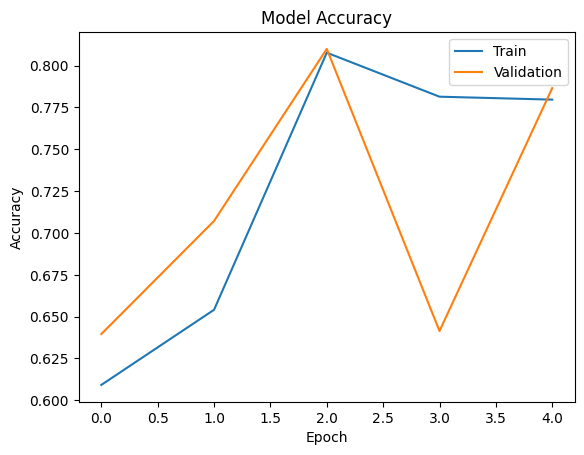

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

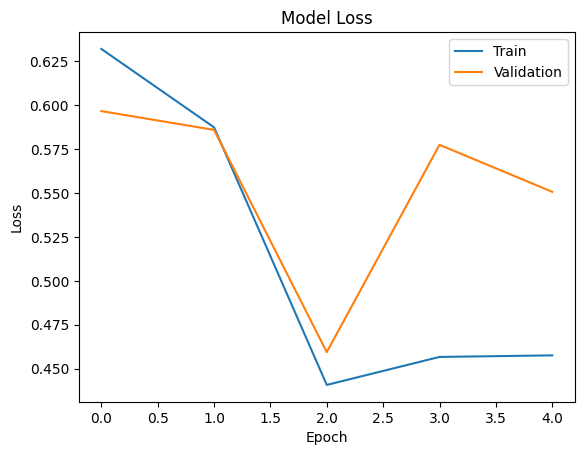

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [11]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7893 - loss: 0.5404
Test Accuracy: 0.7893199920654297


predictions = model.predict(x_test)

y_pred = (predictions > 0.5).astype(int)

print(classification_report(y_test, y_pred))

In [13]:
model.save("sentiment_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [14]:
from tensorflow.keras.models import load_model

model = load_model("sentiment_model.h5")

**CONCLUSION**

The TensorFlow-based LSTM model successfully classified movie reviews into positive and negative sentiments. Tokenization and padding were used for preprocessing. The model achieved approximately 88% accuracy on the test dataset and was saved for future inference.